In [33]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

import mcstasscript as ms
import mcstastox as mx
import scipp as sc
import plopp as pp

module_source = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(module_source)

from trex_reduction import (
    generate_bins,
    inelastic,
    _calc_pulse_centroid,
    produce_trex_event_object,
)

In [34]:
exp_folder = "TREX_vanad_1"
file_path = os.path.join(module_source, "mdnorm", "runs", exp_folder)

with mx.Read(file_path) as loaded_data:
    scipp_object = loaded_data.export_scipp(
        source_name="ESS_source",
        sample_name="Sample",
    )


data = ms.load_data(file_path)

for mon in data:
    mon.set_title(mon.name)
lambda_tom = ms.name_search("Cheat_lambda_tof_monitor", data)


event_object = scipp_object
# McStas provides absolute time, not time of flight
event_object["events"].bins.coords["tof"] = event_object["events"].bins.coords[
    "t"
]  # + sc.scalar(2.86e-3/2, unit = 's')
# Add additional information required for inelastic scattering
event_object

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 28343}),
    positions: Variable({'pixel_id': 30056}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

In [35]:
data

[
 McStasData: B1_monitor_lam type: 1D  I:0.0 E:0.0 N:0.0,
 
 McStasData: BW1_monitor_ToF type: 1D  I:672380000.0 E:105680.0 N:116590000.0,
 
 McStasData: B1_monitor_xy type: 2D  I:680949000.0 E:106319.0 N:118630000.0,
 
 McStasData: BW2_monitor_lam type: 1D  I:0.0 E:0.0 N:0.0,
 
 McStasData: BW2_monitor_ToF type: 1D  I:537296000.0 E:90583.3 N:103004000.0,
 
 McStasData: B2_monitor_xy type: 2D  I:548581000.0 E:91537.8 N:105266000.0,
 
 McStasData: M_monitor_flux type: 0D  I:1138700.0 E:4230.57 N:96647.0,
 
 McStasData: M_monitor_hdiv type: 1D  I:1138700.0 E:4230.57 N:96647.0,
 
 McStasData: M_monitor_lam type: 1D  I:1138700.0 E:4230.57 N:96647.0,
 
 McStasData: M_monitor_ToF type: 1D  I:1138700.0 E:4230.57 N:96647.0,
 
 McStasData: M_monitor_vdiv type: 1D  I:1138700.0 E:4230.57 N:96647.0,
 
 McStasData: M_monitor_xy type: 2D  I:1138730.0 E:4230.65 N:96649.0,
 
 McStasData: P_monitor_lam type: 1D  I:32945600.0 E:22024.1 N:7310280.0,
 
 McStasData: P_monitor_ToF_2 type: 1D  I:953795.0 E:

Skipped plotting Trex_banana_det as it contains event data.


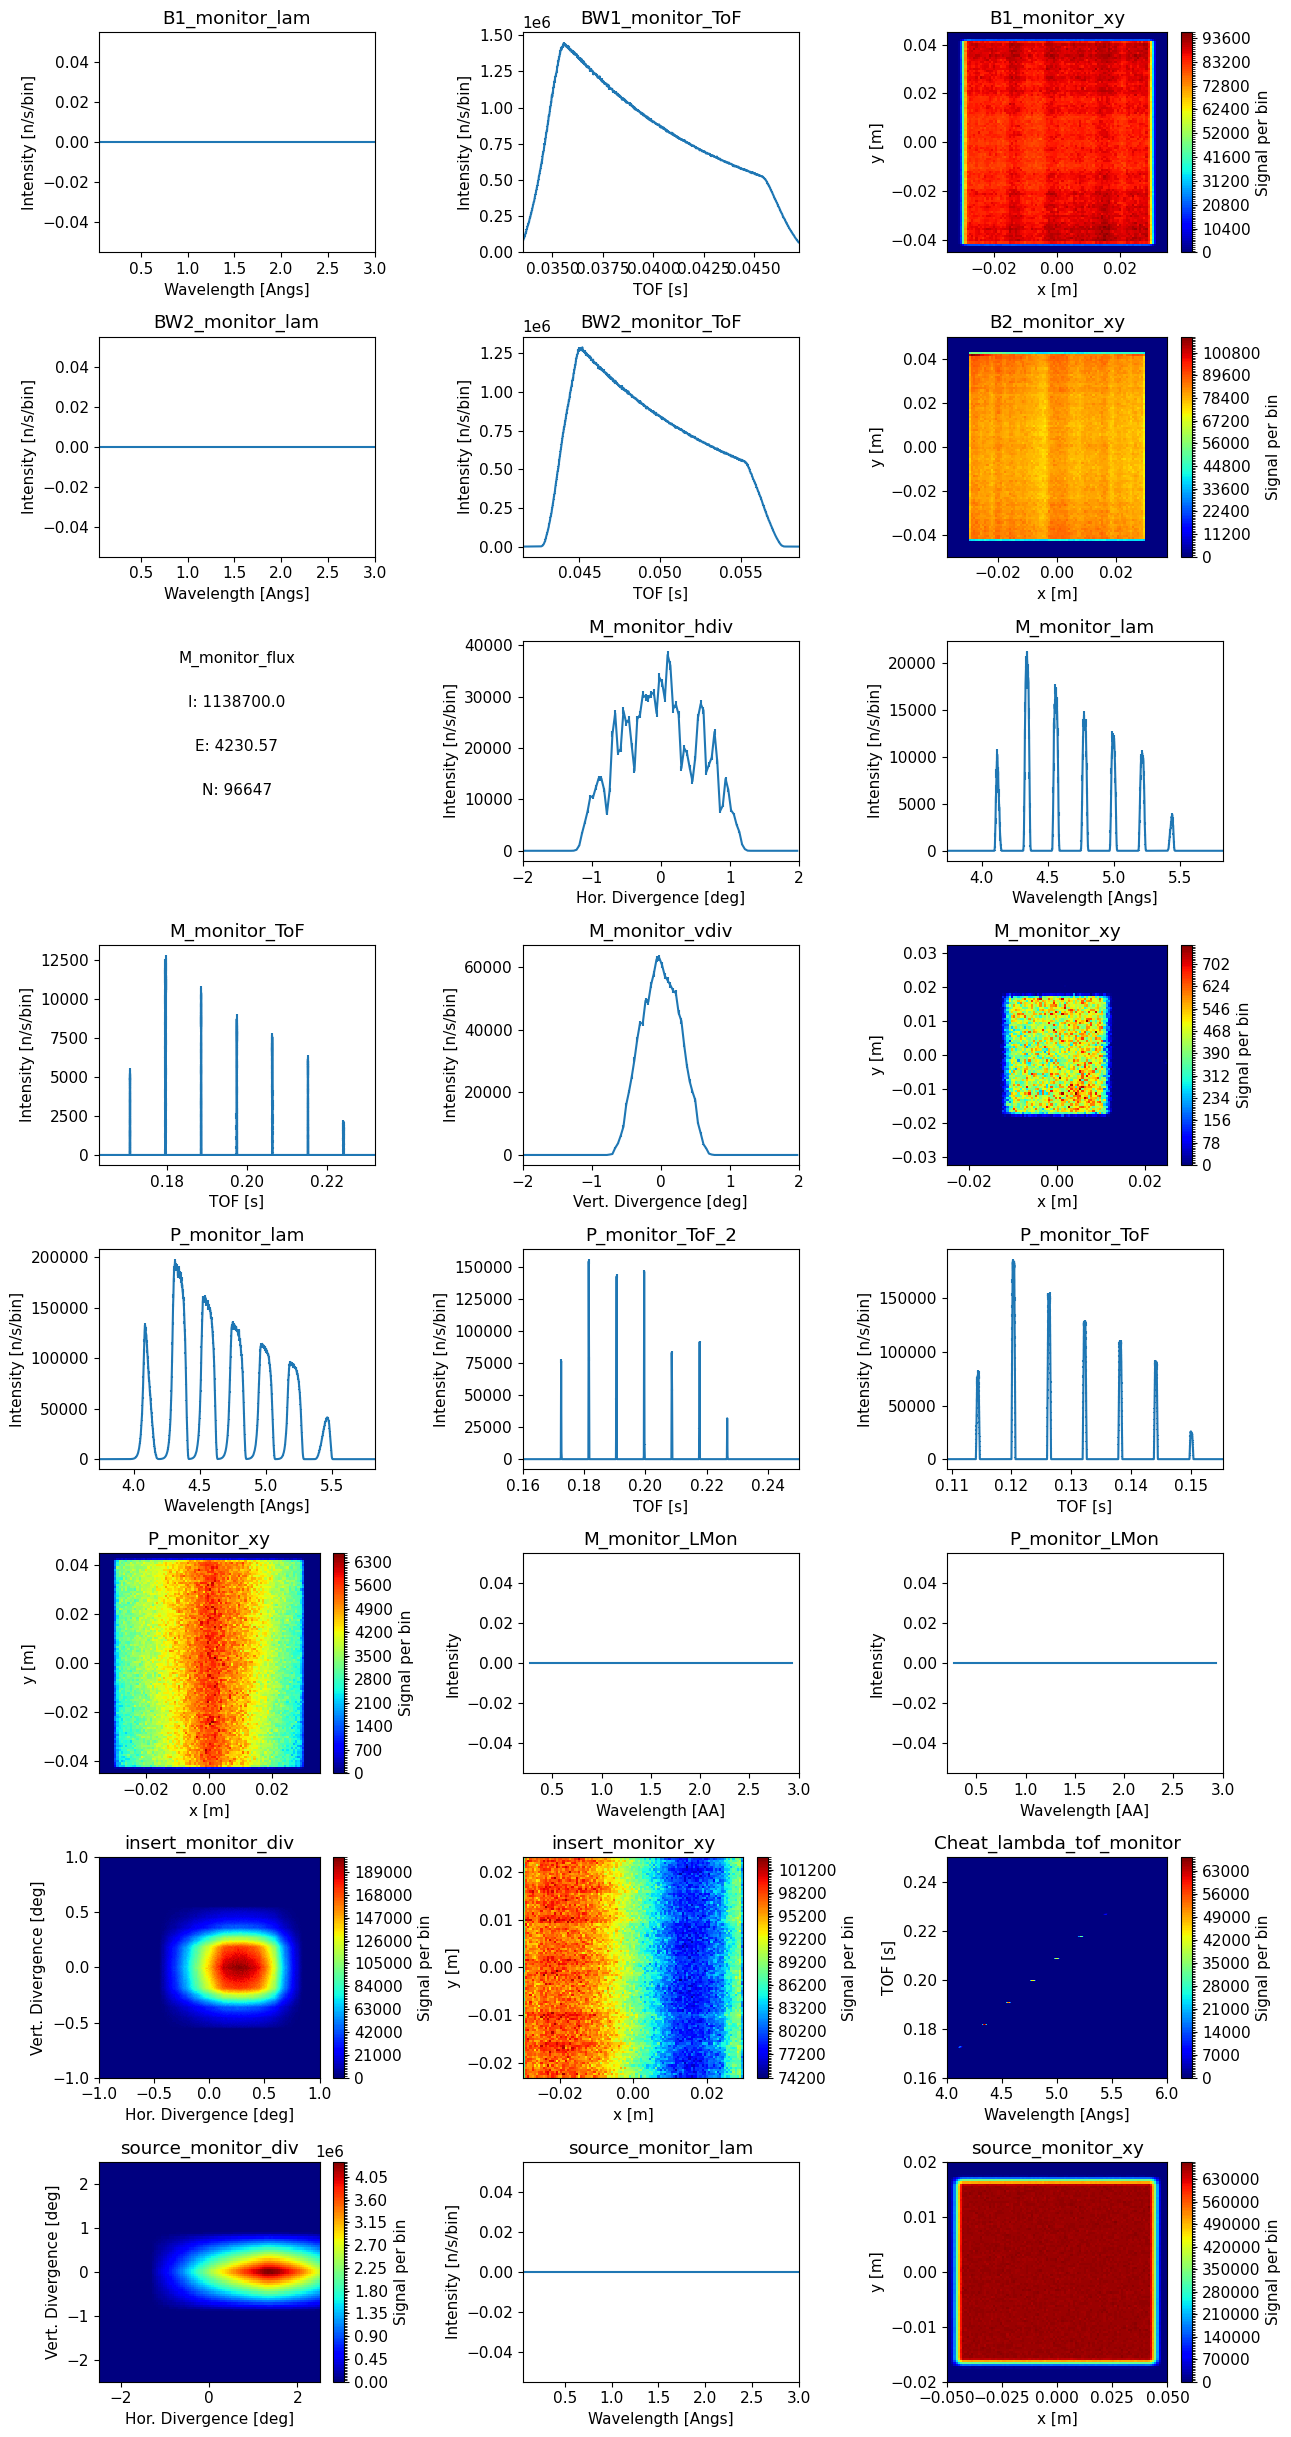

In [36]:
ms.make_sub_plot(data)

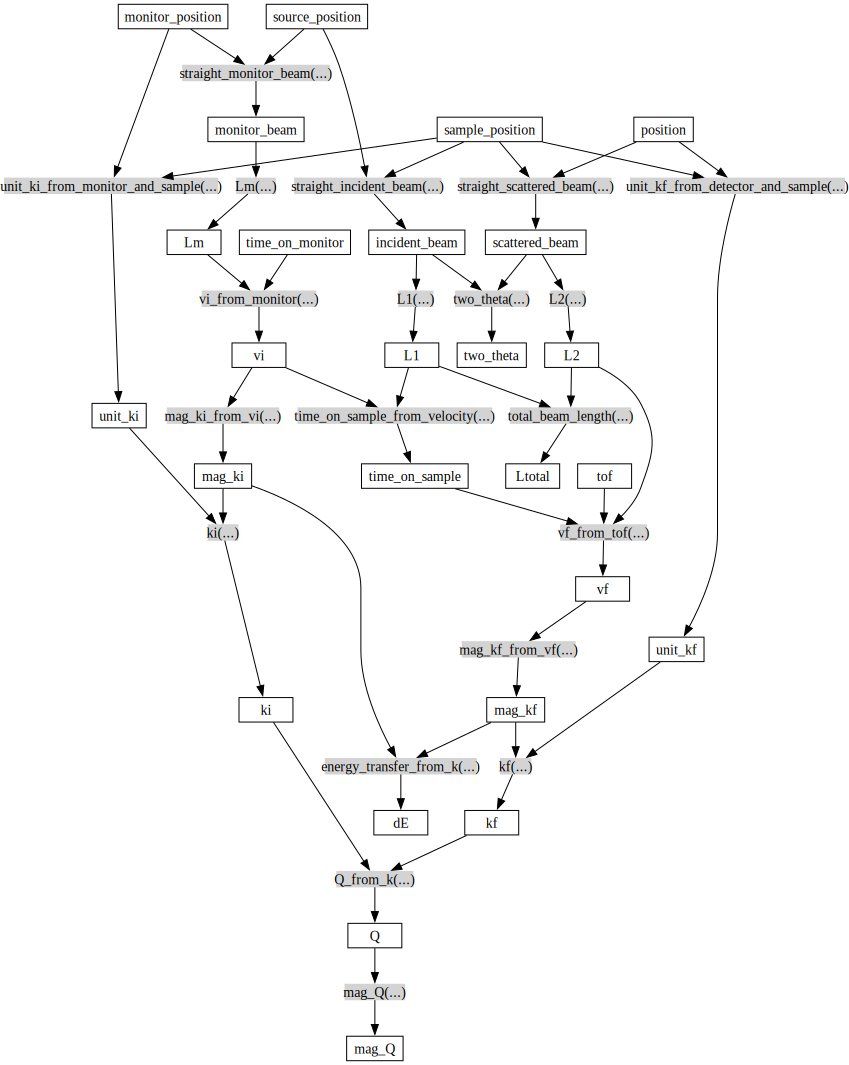

In [37]:
from scippneutron.conversion.graph.beamline import beamline

event_object["events"] = produce_trex_event_object(
    event_object["events"], file_path, "P_monitor_ToF_2", to_s=1
)
qens_graph = {**beamline(scatter=True), **inelastic}
sc.show_graph(qens_graph)

In [38]:
event_object["events"] = event_object["events"].transform_coords("dE", graph=qens_graph)
event_object["events"] = event_object["events"].transform_coords(
    "mag_Q", graph=qens_graph
)

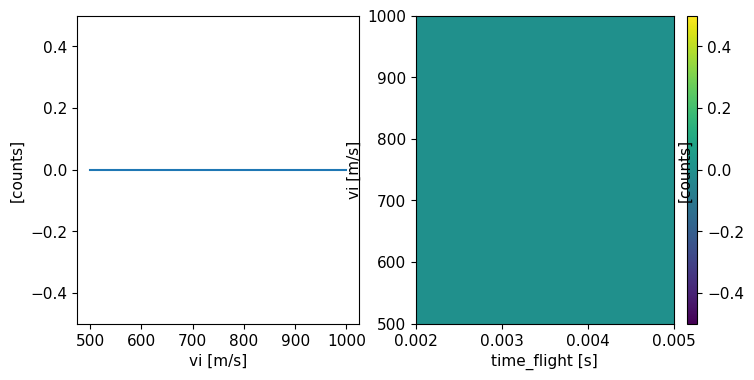

In [39]:
# Apply mask to the binned variable
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

event_object["events"].bins.coords["time_flight"] = (
    event_object["events"].bins.coords["tof"]
    - event_object["events"].bins.coords["time_on_monitor"]
)

vi_range = sc.array(values=np.linspace(500, 1000, 300), unit="m/s", dims=["vi"])
event_object["events"].bin(vi=vi_range).sum("pixel_id").plot(
    ax=ax[0], linestyle="-", color="tab:blue"
)

tom_range = sc.array(
    values=np.linspace(0.16, 0.24, 50), unit="s", dims=["time_on_monitor"]
)
tof_range = sc.array(values=np.linspace(0.16, 0.24, 50), unit="s", dims=["tof"])
time_flight_range = sc.array(
    values=np.linspace(0.002, 0.005, 50), unit="s", dims=["time_flight"]
)
event_object["events"].bin(vi=vi_range, time_flight=time_flight_range).sum(
    "pixel_id"
).plot(ax=ax[1])
plt.show()

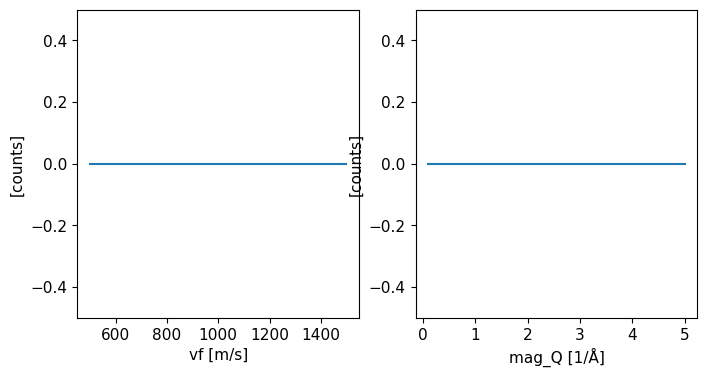

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))


# Apply mask to the binned variable
vf_range = sc.array(values=np.linspace(500, 1500, 300), unit="m/s", dims=["vf"])
event_object["events"].bin(vf=vf_range).sum("pixel_id").plot(
    ax=ax[0], linestyle="-", color="tab:blue"
)
# ax.set_xlim(0,2000)

# mask = event_object.coords['vf'] < sc.scalar(5000, unit=event_object.coords['vf'].unit)
Q_range = sc.array(values=np.linspace(0.1, 5, 300), unit="1/Angstrom", dims=["mag_Q"])
event_object["events"].bin(mag_Q=Q_range).sum("pixel_id").plot(
    ax=ax[1], linestyle="-", color="tab:blue"
)

plt.show()